# 520 Midterm Project

Import Modules and Libraries

In [62]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz

Import and transform data

In [78]:
# Load the dataset
file_id = "1dptD0F692OUEHrrU8APfjknm344Ahi3p"
url = f'https://drive.google.com/uc?id={file_id}'

p1_high_emg = pd.read_csv(url)

file_id = "11AQFyHUNdBHuUwpY0jlQSkkEymwhEKcg"
url = f'https://drive.google.com/uc?id={file_id}'

p1_low_emg = pd.read_csv(url)

file_id = "1JIrKi1tqr6BmqBelZFS-4sxhomo9iXyN"
url = f'https://drive.google.com/uc?id={file_id}'

p2_high_emg = pd.read_csv(url)

file_id = "1_2M2jIP94v2kdCsTLiwbEIdiifESGcIb"
url = f'https://drive.google.com/uc?id={file_id}'

p2_low_emg = pd.read_csv(url)

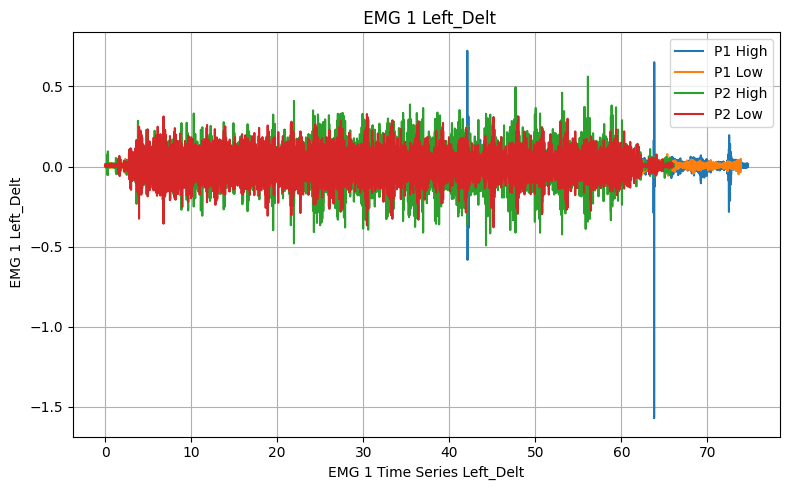

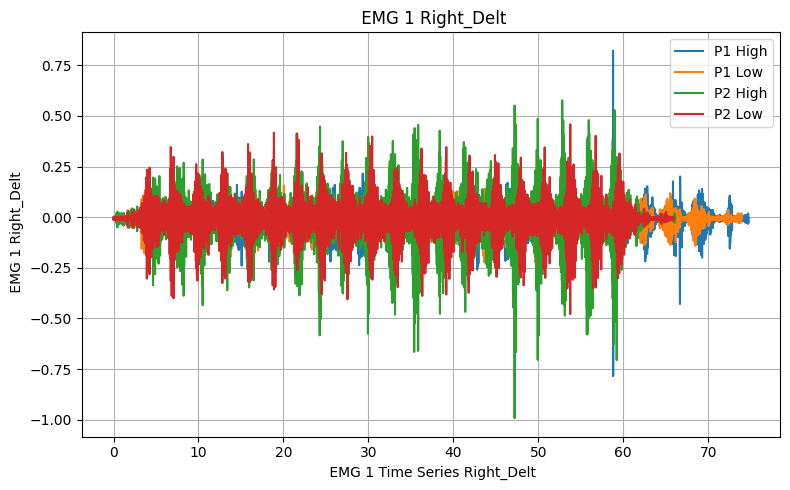

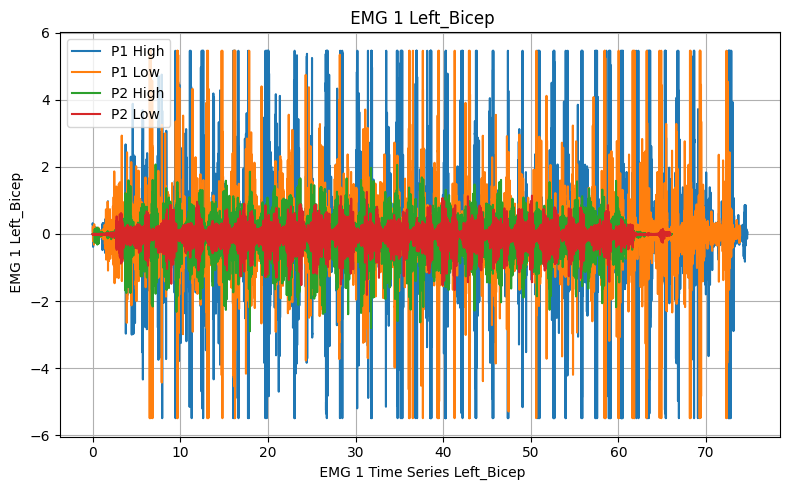

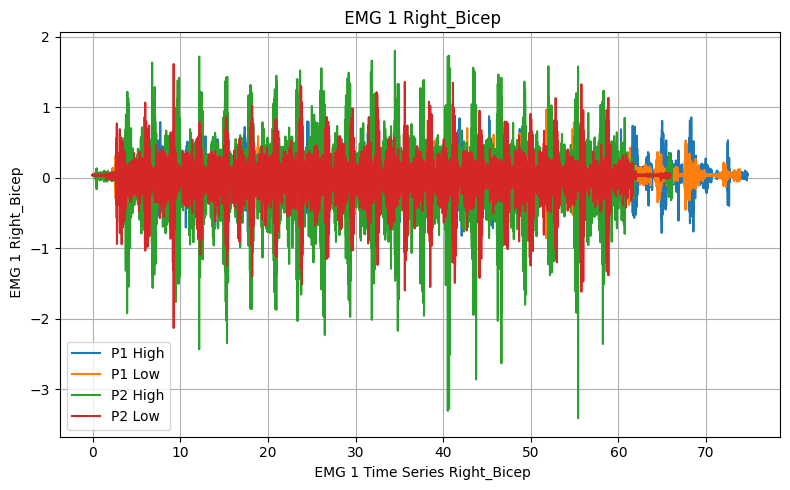

In [67]:
# Plot Input Data (For Visualization Purposes)

# Example dataframes (replace these with your actual ones)
dfs = [p1_high_emg, p1_low_emg, p2_high_emg, p2_low_emg]
labels = ['P1 High', 'P1 Low', 'P2 High', 'P2 Low']

# Get the column names (assumes they’re all the same)
columns = p1_high_emg.columns

# Create one figure per column
for i in range(0, 8, 2):
    plt.figure(figsize=(8, 5))
    for j, df in enumerate(dfs):
        plt.plot(df.iloc[:, i], df.iloc[:, i+1], label=labels[j])
    plt.title(columns[i+1])
    plt.xlabel(columns[i])
    plt.ylabel(columns[i+1])
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [68]:
# Split Data into 4s intervals (each lift)

emg_bins = []
emg_src = []
binNumber = 0
startIndex = 0

# Append P1 High
for dataValue in range(len(p1_high_emg.index)):
  if (math.floor(p1_high_emg.iloc[dataValue, 0] / 4) > binNumber):
    emg_bins.append(p1_high_emg.iloc[startIndex:dataValue - 1])
    emg_src.append("high")
    startIndex = dataValue
    binNumber += 1

# Append P1 Low
binNumber = 0
startIndex = 0
for dataValue in range(len(p1_low_emg.index)):
  if (math.floor(p1_low_emg.iloc[dataValue, 0] / 4) > binNumber):
    emg_bins.append(p1_low_emg.iloc[startIndex:dataValue - 1])
    emg_src.append("low")
    startIndex = dataValue
    binNumber += 1

# Append P2 High
binNumber = 0
startIndex = 0
for dataValue in range(len(p2_high_emg.index)):
  if (math.floor(p2_high_emg.iloc[dataValue, 0] / 4) > binNumber):
    emg_bins.append(p2_high_emg.iloc[startIndex:dataValue - 1])
    emg_src.append("high")
    startIndex = dataValue
    binNumber += 1

# Append P2 Low
binNumber = 0
startIndex = 0
for dataValue in range(len(p2_low_emg.index)):
  if (math.floor(p2_low_emg.iloc[dataValue, 0] / 4) > binNumber):
    emg_bins.append(p2_low_emg.iloc[startIndex:dataValue - 1])
    emg_src.append("low")
    startIndex = dataValue
    binNumber += 1

cols_to_drop = ['EMG 1 Time Series Left_Delt',
                ' EMG 1 Time Series Right_Delt',
                ' EMG 1 Time Series Left_Bicep',
                ' EMG 1 Time Series Right_Bicep']

cleaned_emg_bins = [
    df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    for df in emg_bins
]
for bin in cleaned_emg_bins:
  bin.columns = bin.columns.str.strip()

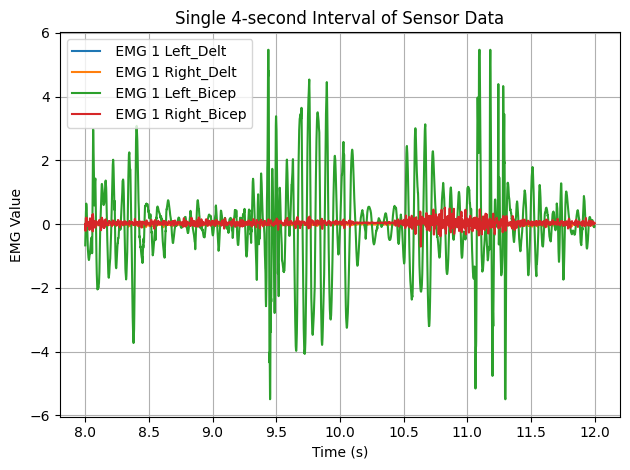

In [69]:
# Plot specific columns, e.g., 'col1' and 'col2'
df = emg_bins[2]
x_col_index = 0           # 5th column (Python is 0-indexed)
y_col_indices = [1, 3, 5, 7]  # First 4 columns

# Extract column names
x_col = df.columns[x_col_index]
y_cols = df.columns[y_col_indices]

# Plot
df.plot(x=x_col, y=y_cols, kind='line', title='Single 4-second Interval of Sensor Data')

# Customize plot
plt.xlabel("Time (s)")
plt.ylabel('EMG Value')
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
# Calculate mean, max, min, std dev, and rms
summary_bins = []

for df in cleaned_emg_bins:
    summary = pd.DataFrame(index=df.columns)

    summary['mean'] = df.mean()
    summary['max'] = df.max()
    summary['min'] = df.min()
    summary['std'] = df.std()
    summary['rms'] = np.sqrt((df**2).mean())

    summary_bins.append(summary)

summary_bins[14].info()

# Flatten all summary DataFrames into a single 2D DataFrame
flat_features = []

for df in summary_bins:
    flat_row = df.stack().T
    flat_features.append(flat_row)

# Combine into one DataFrame
X = pd.DataFrame(flat_features)
y = pd.Series(emg_src)

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, EMG 1 Left_Delt to EMG 1 Right_Bicep
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mean    4 non-null      float64
 1   max     4 non-null      float64
 2   min     4 non-null      float64
 3   std     4 non-null      float64
 4   rms     4 non-null      float64
dtypes: float64(5)
memory usage: 364.0+ bytes


In [71]:
# Categorize and prepare data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10, stratify=y)

## Logistic Regression Model

Instantiate and train model

In [72]:
# Initialize a logistic regression model
logisticModel = LogisticRegression(penalty='l2')

# Fit the model
logisticModel.fit(X_train, np.ravel(y_train))

# Print the fitted model
print(logisticModel.intercept_)
print(logisticModel.coef_)

[5.86252328]
[[-1.65756379e-04 -4.74280856e-01  3.32524038e-01 -1.18175319e-02
  -1.03804566e-02 -4.49245149e-04 -1.70250874e-01  3.33316311e-01
  -1.08096084e-02 -1.07672661e-02  1.65521575e-03  1.72877770e-01
   5.39093210e-01 -9.64797487e-01 -9.64744377e-01  5.28705580e-04
  -1.19580462e+00  1.63732239e+00 -2.50245372e-01 -2.31843077e-01]]


Test model

Logistic regression model accuracy: 0.9047619047619048
Logistic regression model f1 score: 0.9047619047619048


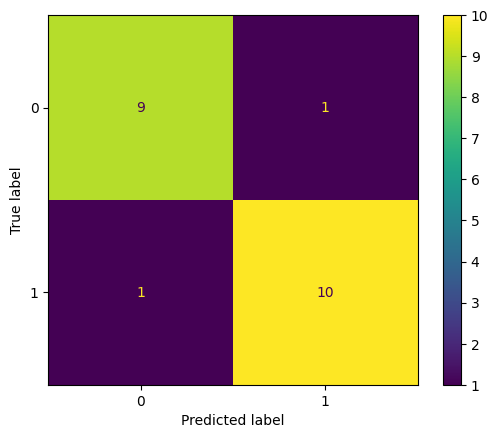

In [73]:
# Calculate predicted probabilities for the first 10 instances
logisticModel.predict_proba(X_test)[0:10]

# Classify the first 10 instances
y_pred = logisticModel.predict(X_test)

# Calculate the proportion of instances correctly classified
logisticModelScore = logisticModel.score(X_test, np.ravel(y_test))
print("Logistic regression model accuracy: " + str(logisticModelScore))
LRf1 = f1_score(y_test, logisticModel.predict(X_test), average='weighted')
print("Logistic regression model f1 score: " + str(LRf1))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Decision Tree Model

Instantiate and train model

[Text(0.4, 0.8333333333333334, "('EMG 1 Right_Bicep', 'rms') <= 0.081\ngini = 0.5\nsamples = 47\nvalue = [24.0, 23.0]"),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, "('EMG 1 Left_Bicep', 'max') <= 1.082\ngini = 0.375\nsamples = 32\nvalue = [24, 8]"),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 23\nvalue = [23, 0]')]

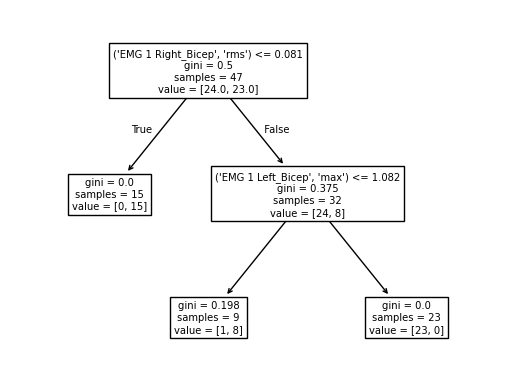

In [74]:
# Split train & test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10, stratify=y)

# Create and train decision tree model
DTC = DecisionTreeClassifier(min_samples_split=15)
DTC.fit(X_train, y_train)

# Plot the fitted tree
plot_tree(DTC, feature_names=X_train.columns)

Test model

Decision tree model accuracy: 0.7619047619047619
Decision Tree model f1 score: 0.7586357197341178


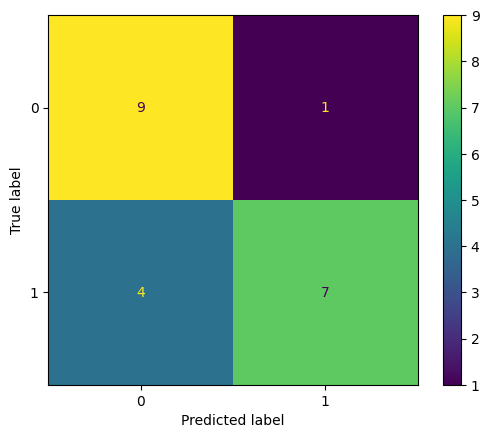

In [75]:
# Predict for the test set and plot the confusion matrix
y_pred = DTC.predict(X_test)
DecisionTreeScore = DTC.score(X_test, y_test)
print("Decision tree model accuracy: " + str(DecisionTreeScore))
DTf1 = f1_score(y_test, DTC.predict(X_test), average='weighted')
print("Decision Tree model f1 score: " + str(DTf1))
cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm).plot()

## K-Nearest Neighbors Model

Instantiate and train model

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10,stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

KNNModel = KNeighborsClassifier(n_neighbors=5)
KNNModel.fit(X_train_scaled, y_train)

KNeighborsClassifier()

Test model

K-nearest neighbors model accuracy: 0.9523809523809523
K-nearest neighbors model f1 score: 0.9521630162362427


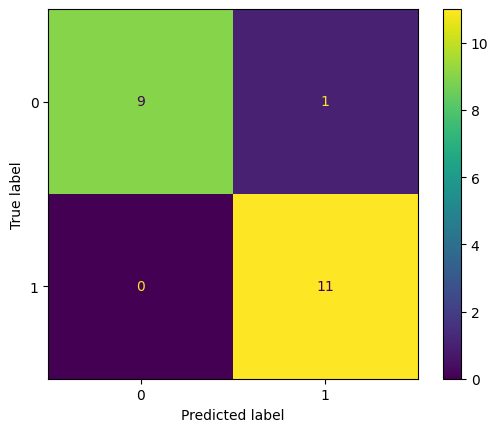

In [77]:
KNNscore=KNNModel.score(X_test_scaled, y_test)
print("K-nearest neighbors model accuracy: " + str(KNNscore))
KNNf1 = f1_score(y_test, KNNModel.predict(X_test_scaled), average='weighted')
print("K-nearest neighbors model f1 score: " + str(KNNf1))
y_pred = KNNModel.predict(X_test_scaled)
cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm).plot()